# 🚕 NYC Taxi Trip Duration — Big Data Project
### PySpark End-to-End Pipeline

**Problem type:** Regression — predict trip duration in seconds  
**Dataset:** NYC Taxi Trip Duration — 1,458,644 rows  
**Engine:** PySpark MLlib  

| Step | Description |
|------|-------------|
| 1 | Data Acquisition |
| 2 | Exploratory Data Analysis |
| 3 | Data Cleaning & Preprocessing |
| 4 | Feature Engineering |
| 5 | Model Development (LR · RF · GBT) |
| 6 | Model Evaluation |
| 7 | Export Streamlit App |

In [2]:
import os
import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType, IntegerType

from pyspark.ml.feature import VectorAssembler, StandardScaler

from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor

from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

✓ All imports successful


---
## 🔥 1. Start Spark Session

In [ ]:
spark = (
    SparkSession.builder
    .appName("NYC_Taxi_Trip_Duration")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .master("local[*]")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

✓ Spark session started — 4.1.1


---
## 📥 2. Data Acquisition

> **Note:** Put `train.csv` in the same folder as this notebook, **or** change `DATA_PATH` below.

In [ ]:
DATA_PATH = "train.csv"

df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(DATA_PATH)
)

print(f"Rows : {df.count():,}")
print(f"Cols : {len(df.columns)}")
df.printSchema()

Rows : 1,458,644
Cols : 11
root
 |-- id: string (nullable = true)
 |-- vendor_id: integer (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- trip_duration: integer (nullable = true)



In [ ]:
df.show(5, truncate=False)

+---------+---------+-------------------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+
|id       |vendor_id|pickup_datetime    |dropoff_datetime   |passenger_count|pickup_longitude  |pickup_latitude   |dropoff_longitude |dropoff_latitude  |store_and_fwd_flag|trip_duration|
+---------+---------+-------------------+-------------------+---------------+------------------+------------------+------------------+------------------+------------------+-------------+
|id2875421|2        |2016-03-14 17:24:55|2016-03-14 17:32:30|1              |-73.9821548461914 |40.76793670654297 |-73.96463012695312|40.765602111816406|N                 |455          |
|id2377394|1        |2016-06-12 00:43:35|2016-06-12 00:54:38|1              |-73.98041534423828|40.738563537597656|-73.99948120117188|40.73115158081055 |N                 |663          |
|id3858529|2        |2016-01-19 11:35:24|2016-01-19 12:10:48|1   

---
## 🔍 3. Exploratory Data Analysis (EDA)

In [ ]:
df.select(
    "trip_duration", "passenger_count",
    "pickup_longitude", "pickup_latitude",
    "dropoff_longitude", "dropoff_latitude"
).describe().show()

+-------+-----------------+------------------+-------------------+-------------------+-------------------+-------------------+
|summary|    trip_duration|   passenger_count|   pickup_longitude|    pickup_latitude|  dropoff_longitude|   dropoff_latitude|
+-------+-----------------+------------------+-------------------+-------------------+-------------------+-------------------+
|  count|          1458644|           1458644|            1458644|            1458644|            1458644|            1458644|
|   mean|959.4922729603659|1.6645295219395548| -73.97348630489282| 40.750920908391734|  -73.9734159469458|   40.7517995149002|
| stddev|5237.431724497624|1.3142421678231184| 0.0709018584227024|0.03288118625763354|0.07064326809720078|0.03589055560563687|
|    min|                1|                 0|-121.93334197998047|  34.35969543457031|-121.93330383300781|   32.1811408996582|
|    max|          3526282|                 9| -61.33552932739258|  51.88108444213867| -61.33552932739258|  43.

In [ ]:
df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+---+---------+---------------+----------------+---------------+----------------+---------------+-----------------+----------------+------------------+-------------+
| id|vendor_id|pickup_datetime|dropoff_datetime|passenger_count|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|store_and_fwd_flag|trip_duration|
+---+---------+---------------+----------------+---------------+----------------+---------------+-----------------+----------------+------------------+-------------+
|  0|        0|              0|               0|              0|               0|              0|                0|               0|                 0|            0|
+---+---------+---------------+----------------+---------------+----------------+---------------+-----------------+----------------+------------------+-------------+



In [ ]:
# 3.3 — Collect aggregates to Pandas for plotting
duration_pd = (
    df.select("trip_duration")
    .filter(F.col("trip_duration") < 7200)
    .toPandas()
)

hour_counts = (
    df.withColumn("hour", F.hour("pickup_datetime"))
    .groupBy("hour").count()
    .orderBy("hour")
    .toPandas()
)

dow_counts = (
    df.withColumn("dow", F.dayofweek("pickup_datetime"))
    .groupBy("dow").count()
    .orderBy("dow")
    .toPandas()
)
dow_counts["day"] = dow_counts["dow"].map(
    {1:"Sun",2:"Mon",3:"Tue",4:"Wed",5:"Thu",6:"Fri",7:"Sat"}
)

pax_counts = (
    df.groupBy("passenger_count").count()
    .orderBy("passenger_count")
    .toPandas()
)

vendor_pd = df.groupBy("vendor_id").count().toPandas()

coords_pd = df.select("pickup_longitude", "pickup_latitude").sample(0.005, seed=42).toPandas()

print("✓ Aggregates collected")

✓ Aggregates collected


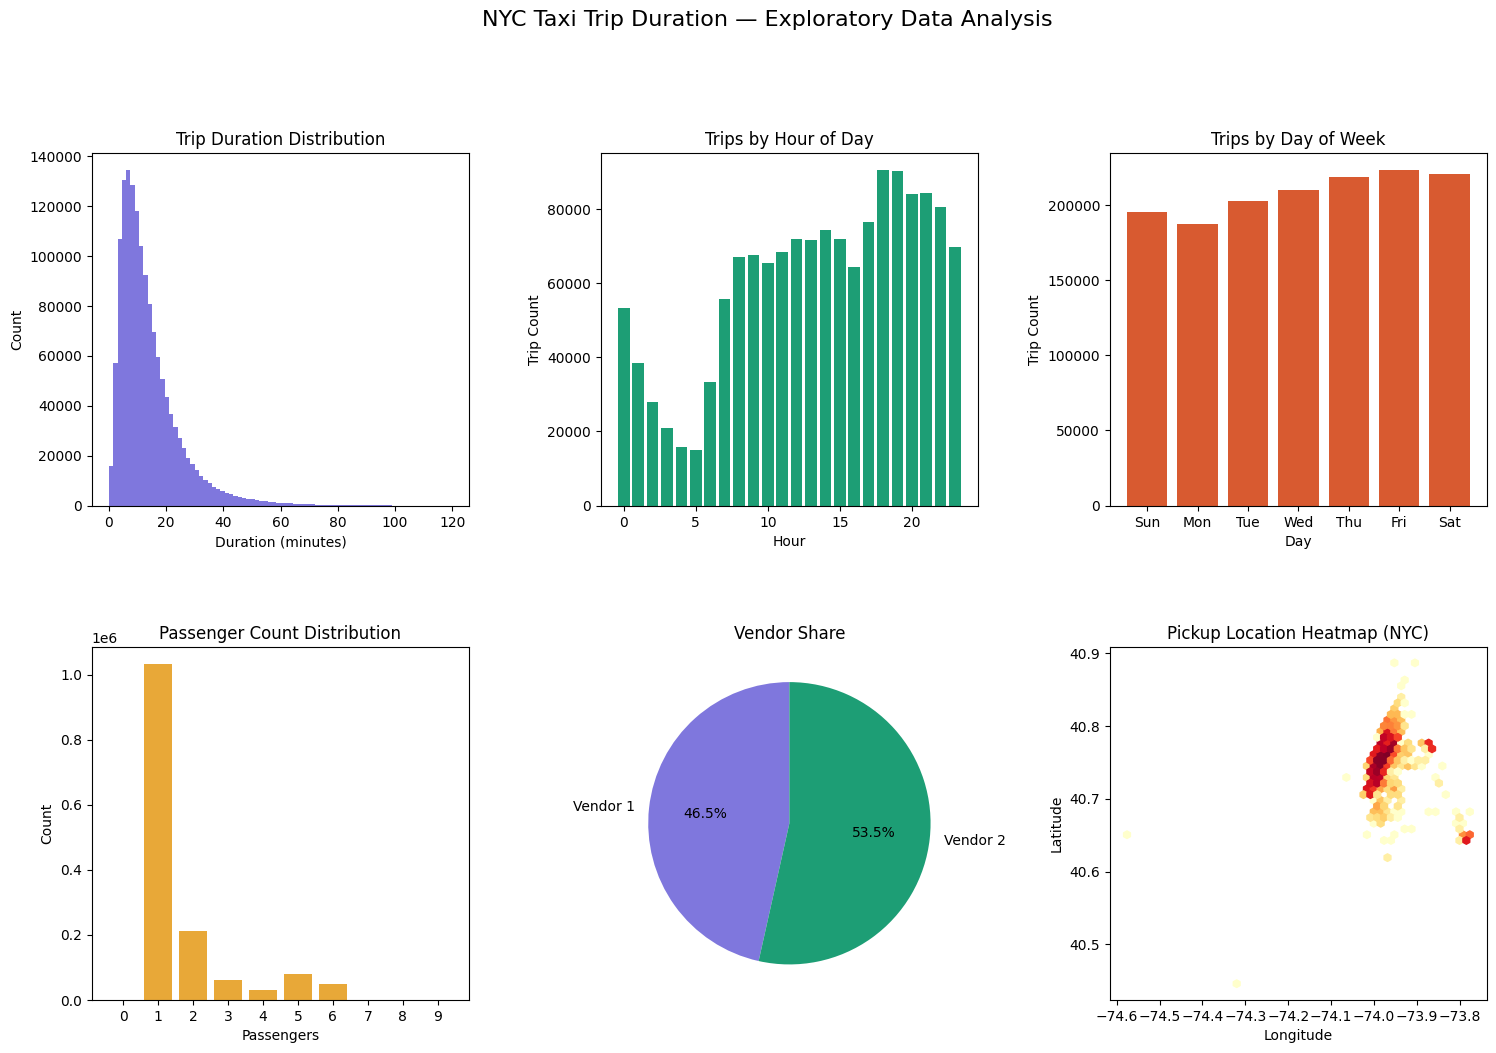

✓ Saved → eda_plots.png


In [ ]:
# 3.4 — EDA Plots
fig = plt.figure(figsize=(18, 11))
fig.suptitle("NYC Taxi Trip Duration — Exploratory Data Analysis", fontsize=16, y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(duration_pd["trip_duration"] / 60, bins=80, color="#7F77DD", edgecolor="none")
ax1.set_title("Trip Duration Distribution")
ax1.set_xlabel("Duration (minutes)")
ax1.set_ylabel("Count")

ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(hour_counts["hour"], hour_counts["count"], color="#1D9E75", edgecolor="none")
ax2.set_title("Trips by Hour of Day")
ax2.set_xlabel("Hour")
ax2.set_ylabel("Trip Count")

ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(dow_counts["day"], dow_counts["count"], color="#D85A30", edgecolor="none")
ax3.set_title("Trips by Day of Week")
ax3.set_xlabel("Day")
ax3.set_ylabel("Trip Count")

ax4 = fig.add_subplot(gs[1, 0])
ax4.bar(pax_counts["passenger_count"].astype(str), pax_counts["count"],
        color="#E8A838", edgecolor="none")
ax4.set_title("Passenger Count Distribution")
ax4.set_xlabel("Passengers")
ax4.set_ylabel("Count")

ax5 = fig.add_subplot(gs[1, 1])
ax5.pie(vendor_pd["count"], labels=[f"Vendor {v}" for v in vendor_pd["vendor_id"]],
        autopct="%1.1f%%", colors=["#7F77DD", "#1D9E75"], startangle=90)
ax5.set_title("Vendor Share")

ax6 = fig.add_subplot(gs[1, 2])
ax6.hexbin(coords_pd["pickup_longitude"], coords_pd["pickup_latitude"],
        gridsize=50, cmap="YlOrRd", bins="log")
ax6.set_title("Pickup Location Heatmap (NYC)")
ax6.set_xlabel("Longitude")
ax6.set_ylabel("Latitude")

plt.savefig("plots/eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 🧹 4. Data Cleaning & Preprocessing

In [ ]:
n_before = df.count()

#Remove duplicates
df = df.dropDuplicates()
print(f"Duplicates removed  : {n_before - df.count():,}")

#Drop nulls in critical columns
critical_cols = [
    "pickup_datetime", "dropoff_datetime",
    "pickup_longitude", "pickup_latitude",
    "dropoff_longitude", "dropoff_latitude",
    "trip_duration"
]
df = df.dropna(subset=critical_cols)

#Remove trip_duration outliers (keep 1 min – 2 hours)
df = df.filter(
    (F.col("trip_duration") >= 60) &
    (F.col("trip_duration") <= 7200)
)

#Remove impossible coordinates (NYC bounding box)
df = df.filter(
    (F.col("pickup_longitude").between(-74.25, -73.70))  &
    (F.col("pickup_latitude").between(40.50, 40.95))     &
    (F.col("dropoff_longitude").between(-74.25, -73.70)) &
    (F.col("dropoff_latitude").between(40.50, 40.95))
)

#Remove impossible passenger counts
df = df.filter(
    (F.col("passenger_count") >= 1) &
    (F.col("passenger_count") <= 6)
)

print(f"Rows after cleaning : {df.count():,}")

Duplicates removed  : 0
Rows after cleaning : 1,446,817


---
## 🔧 5. Feature Engineering

| Feature | Source | Description |
|---------|--------|-------------|
| pickup_hour | pickup_datetime | 0–23 |
| pickup_dow | pickup_datetime | 1=Sun … 7=Sat |
| pickup_month | pickup_datetime | 1–12 |
| pickup_day | pickup_datetime | 1–31 |
| is_weekend | pickup_dow | 1 if Sat/Sun |
| is_rush_hour | pickup_hour + is_weekend | 1 if 7-9am or 4-7pm on weekday |
| haversine_dist | coordinates | Great-circle distance (km) |
| bearing | coordinates | Direction of travel (0–360°) |
| manhattan_dist | coordinates | Sum of lat/lon differences |
| mid_lat / mid_lon | coordinates | Midpoint of the trip |
| flag_enc | store_and_fwd_flag | 0/1 encoding |
| log_duration | trip_duration | log1p target (for better model fit) |

In [ ]:
def haversine_sql(lat1, lon1, lat2, lon2):
    dlat = F.radians(F.col(lat2) - F.col(lat1))
    dlon = F.radians(F.col(lon2) - F.col(lon1))
    a = (
        F.pow(F.sin(dlat / 2), 2)
        + F.cos(F.radians(F.col(lat1)))
        * F.cos(F.radians(F.col(lat2)))
        * F.pow(F.sin(dlon / 2), 2)
    )
    return F.lit(6371.0) * 2 * F.asin(F.sqrt(a))

def bearing_sql(lat1, lon1, lat2, lon2):
    dlon = F.radians(F.col(lon2) - F.col(lon1))
    x = F.sin(dlon) * F.cos(F.radians(F.col(lat2)))
    y = (F.cos(F.radians(F.col(lat1))) * F.sin(F.radians(F.col(lat2)))
         - F.sin(F.radians(F.col(lat1))) * F.cos(F.radians(F.col(lat2))) * F.cos(dlon))
    return (F.degrees(F.atan2(x, y)) + 360) % 360


✓ Native SQL functions ready — no Python workers needed


In [ ]:
# Temporal features
df = (
    df
    .withColumn("pickup_hour",  F.hour("pickup_datetime"))
    .withColumn("pickup_dow",   F.dayofweek("pickup_datetime"))
    .withColumn("pickup_month", F.month("pickup_datetime"))
    .withColumn("pickup_day",   F.dayofmonth("pickup_datetime"))
    .withColumn("is_weekend",
        F.when(F.col("pickup_dow").isin(1, 7), 1).otherwise(0))
    .withColumn("is_rush_hour",
        F.when(
            ((F.col("pickup_hour").between(7, 9)) |
            (F.col("pickup_hour").between(16, 19))) &
            (F.col("is_weekend") == 0), 1  
    ).otherwise(0))
)

# Geospatial features
df = (
    df
    .withColumn("haversine_dist",
        haversine_sql("pickup_latitude", "pickup_longitude",
                        "dropoff_latitude", "dropoff_longitude"))
    .withColumn("bearing",
        bearing_sql("pickup_latitude", "pickup_longitude",
                    "dropoff_latitude", "dropoff_longitude"))
    .withColumn("manhattan_dist",
        F.abs(F.col("dropoff_latitude")  - F.col("pickup_latitude")) +
        F.abs(F.col("dropoff_longitude") - F.col("pickup_longitude")))
    .withColumn("mid_lat",
        (F.col("pickup_latitude")  + F.col("dropoff_latitude"))  / 2)
    .withColumn("mid_lon",
        (F.col("pickup_longitude") + F.col("dropoff_longitude")) / 2)
)

# Encode flag + log-transform target
df = (
    df
    .withColumn("flag_enc",
        F.when(F.col("store_and_fwd_flag") == "Y", 1).otherwise(0))
    .withColumn("log_duration", F.log1p(F.col("trip_duration")))
)

# Remove zero-distance trips
df = df.filter(F.col("haversine_dist") > 0.01)

print(f"Final row count: {df.count():,}")

✓ Features created. Final row count: 1,442,052


In [ ]:
df.select(
    "trip_duration", "log_duration",
    "pickup_hour", "pickup_dow", "is_weekend", "is_rush_hour",
    "haversine_dist", "bearing", "manhattan_dist"
).show(5)

+-------------+-----------------+-----------+----------+----------+------------+------------------+------------------+--------------------+
|trip_duration|     log_duration|pickup_hour|pickup_dow|is_weekend|is_rush_hour|    haversine_dist|           bearing|      manhattan_dist|
+-------------+-----------------+-----------+----------+----------+------------+------------------+------------------+--------------------+
|          260|5.564520407322694|         20|         4|         0|           0|0.9916848505446173|236.36736000153343|0.014743804931640625|
|         1414|7.254884810077338|          0|         6|         0|           0|  6.38283575627504|13.377653344082319| 0.07338333129882812|
|         1317|7.183870715062453|          9|         2|         0|           1| 4.605201075572881|26.963045286216357| 0.06169891357421875|
|         1163|7.059617628291383|         10|         7|         1|           0| 4.874792360071824|192.57286239851956|0.055377960205078125|
|          553|6.317

---
## 🤖 6. Model Development

Train three regression models using the **PySpark MLlib Pipeline API**.

| Model | Strength |
|-------|----------|
| Linear Regression | Fast, interpretable baseline |
| Random Forest | Handles non-linearity, robust to outliers |
| GBT Regressor | Best accuracy on tabular data |

In [15]:
# Feature columns used by all models
feature_cols = [
    "pickup_hour", "pickup_dow", "pickup_month", "pickup_day",
    "is_weekend", "is_rush_hour",
    "passenger_count", "vendor_id", "flag_enc",
    "haversine_dist", "manhattan_dist", "bearing",
    "pickup_latitude", "pickup_longitude",
    "dropoff_latitude", "dropoff_longitude",
    "mid_lat", "mid_lon",
]

# 80 / 20 train-test split
train_df, test_df = df.randomSplit([0.80, 0.20], seed=42)
train_df.cache()
test_df.cache()
print(f"Train : {train_df.count():,}  |  Test : {test_df.count():,}")

Train : 1,154,160  |  Test : 287,892


In [16]:
# Shared pipeline stages: VectorAssembler → StandardScaler
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="raw_features",
    handleInvalid="skip"
)
scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="features",
    withMean=True, withStd=True
)

# Define the 3 models (target = log_duration)
models_def = {
    "LinearRegression": LinearRegression(
        featuresCol="features", labelCol="log_duration",
        maxIter=100, regParam=0.01, elasticNetParam=0.0,
    ),
    "RandomForest": RandomForestRegressor(
        featuresCol="features", labelCol="log_duration",
        numTrees=100, maxDepth=8, seed=42,
    ),
    "GBTRegressor": GBTRegressor(
        featuresCol="features", labelCol="log_duration",
        maxIter=100, maxDepth=6, stepSize=0.1, seed=42,
    ),
}

# Evaluators on log scale
evaluator_rmse = RegressionEvaluator(
    labelCol="log_duration", predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(
    labelCol="log_duration", predictionCol="prediction", metricName="mae")
evaluator_r2   = RegressionEvaluator(
    labelCol="log_duration", predictionCol="prediction", metricName="r2")

print("✓ Pipeline stages and evaluators ready")

✓ Pipeline stages and evaluators ready


In [17]:
# Train all three models
results     = {}
predictions = {}

for name, regressor in models_def.items():
    print(f"Training {name} …")
    pipeline = Pipeline(stages=[assembler, scaler, regressor])
    model    = pipeline.fit(train_df)
    preds    = model.transform(test_df)

    rmse = evaluator_rmse.evaluate(preds)
    mae  = evaluator_mae.evaluate(preds)
    r2   = evaluator_r2.evaluate(preds)

    results[name]     = {"rmse": rmse, "mae": mae, "r2": r2, "model": model}
    predictions[name] = preds
    print(f"  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}  (log scale)\n")

print("✓ All models trained")

Training LinearRegression …
  RMSE=0.5224  MAE=0.4092  R²=0.4824  (log scale)

Training RandomForest …
  RMSE=0.3845  MAE=0.2929  R²=0.7195  (log scale)

Training GBTRegressor …
  RMSE=0.3203  MAE=0.2357  R²=0.8054  (log scale)

✓ All models trained


In [24]:
import numpy as np
import os

os.makedirs("models", exist_ok=True)

# Linear Regression — بنحفظ كل حاجة
lr_model = results["LinearRegression"]["model"]
np.save("models/LR_coefficients.npy", lr_model.stages[2].coefficients.toArray())
np.save("models/LR_intercept.npy",    np.array([lr_model.stages[2].intercept]))
np.save("models/scaler_mean.npy",     lr_model.stages[1].mean.toArray())
np.save("models/scaler_std.npy",      lr_model.stages[1].std.toArray())
np.save("models/feature_cols.npy",    np.array(feature_cols))

print("✓ LR model saved as numpy arrays")

✓ LR model saved as numpy arrays


---
## 📊 7. Model Evaluation

In [25]:
# Results table
print(f"{'Model':<22} {'RMSE (log)':>12} {'MAE (log)':>12} {'R²':>8}")
print("-" * 58)

best_name, best_r2 = None, -999
for name, res in results.items():
    if res["r2"] > best_r2:
        best_name, best_r2 = name, res["r2"]

for name, res in results.items():
    marker = "  ★ BEST" if name == best_name else ""
    print(f"{name:<22} {res['rmse']:>12.4f} {res['mae']:>12.4f} {res['r2']:>8.4f}{marker}")

print(f"\nBest model : {best_name}  (R² = {best_r2:.4f})")

Model                    RMSE (log)    MAE (log)       R²
----------------------------------------------------------
LinearRegression             0.5224       0.4092   0.4824
RandomForest                 0.3845       0.2929   0.7195
GBTRegressor                 0.3203       0.2357   0.8054  ★ BEST

Best model : GBTRegressor  (R² = 0.8054)


In [26]:
# RMSE on original scale (seconds)
best_preds = (
    predictions[best_name]
    .withColumn("pred_duration",   F.expm1(F.col("prediction")))
    .withColumn("actual_duration", F.col("trip_duration"))
    .select("actual_duration", "pred_duration")
)

evaluator_orig = RegressionEvaluator(
    labelCol="actual_duration",
    predictionCol="pred_duration",
    metricName="rmse"
)
rmse_sec = evaluator_orig.evaluate(best_preds)
print(f"Best model ({best_name})")
print(f"  RMSE : {rmse_sec:.1f} seconds  ({rmse_sec/60:.1f} minutes)")

Best model (GBTRegressor)
  RMSE : 289.5 seconds  (4.8 minutes)


In [27]:
# Collect sample for plots + feature importance
sample_pd = best_preds.sample(fraction=0.002, seed=42).toPandas()

has_importance = best_name in ("RandomForest", "GBTRegressor")
if has_importance:
    reg_model   = results[best_name]["model"].stages[-1]
    importances = reg_model.featureImportances.toArray()
    feat_imp_pd = (
        pd.DataFrame({"feature": feature_cols, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(15)
    )
    feat_imp_pd.to_csv("feature_importance.csv", index=False)

print("✓ Ready for plotting")

✓ Ready for plotting


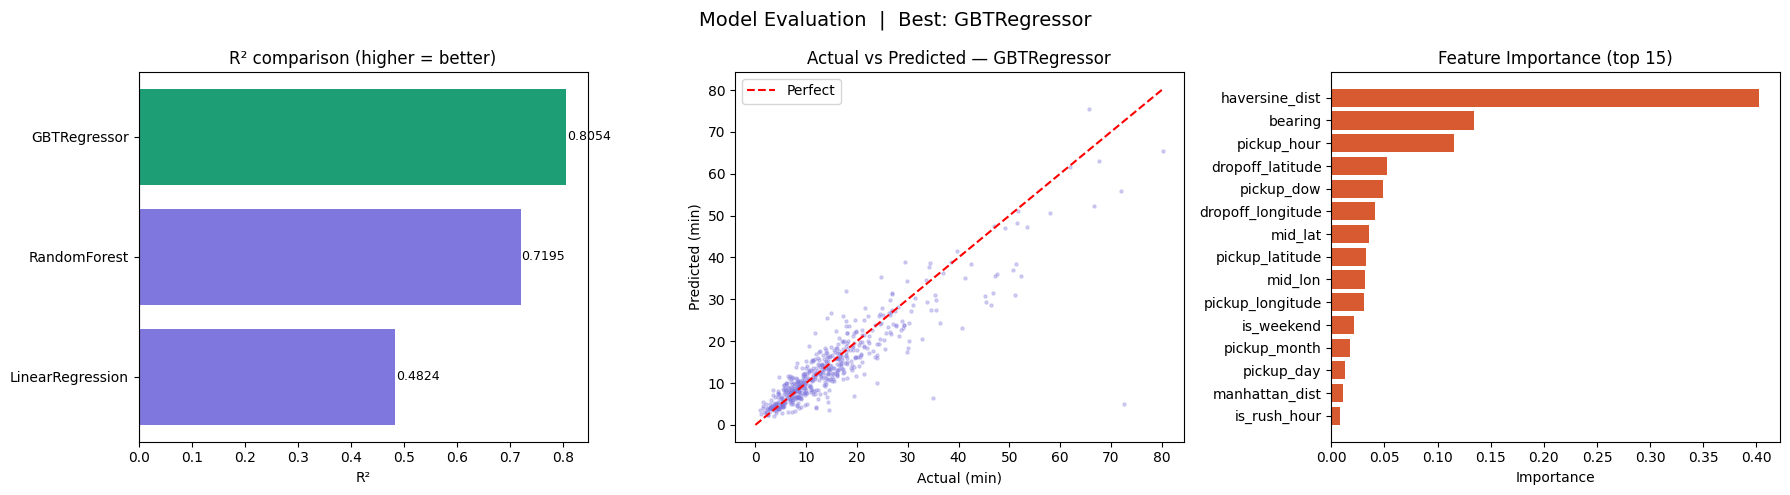

✓ Saved → evaluation_plots.png


In [28]:
# Evaluation plots — R², Actual vs Predicted, Feature Importance
names     = list(results.keys())
r2vals    = [results[n]["r2"]   for n in names]
rmse_vals = [results[n]["rmse"] for n in names]
mae_vals  = [results[n]["mae"]  for n in names]

ncols = 3 if has_importance else 2
fig2, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
fig2.suptitle(f"Model Evaluation  |  Best: {best_name}", fontsize=14)

# Panel 1 — R² comparison
ax = axes[0]
colors = ["#1D9E75" if n == best_name else "#7F77DD" for n in names]
ax.barh(names, r2vals, color=colors, edgecolor="none")
ax.set_xlabel("R²")
ax.set_title("R² comparison (higher = better)")
ax.axvline(0, color="gray", linewidth=0.8)
for i, v in enumerate(r2vals):
    ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9)

# Panel 2 — Actual vs Predicted
ax2 = axes[1]
ax2.scatter(sample_pd["actual_duration"] / 60, sample_pd["pred_duration"] / 60,
            alpha=0.3, s=5, color="#7F77DD")
max_val = max(sample_pd["actual_duration"].max(), sample_pd["pred_duration"].max()) / 60
ax2.plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Perfect")
ax2.set_xlabel("Actual (min)")
ax2.set_ylabel("Predicted (min)")
ax2.set_title(f"Actual vs Predicted — {best_name}")
ax2.legend()

# Panel 3 — Feature Importance
if has_importance:
    ax3 = axes[2]
    ax3.barh(feat_imp_pd["feature"][::-1], feat_imp_pd["importance"][::-1],
             color="#D85A30", edgecolor="none")
    ax3.set_xlabel("Importance")
    ax3.set_title("Feature Importance (top 15)")

plt.tight_layout()
plt.savefig("plots/evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → evaluation_plots.png")

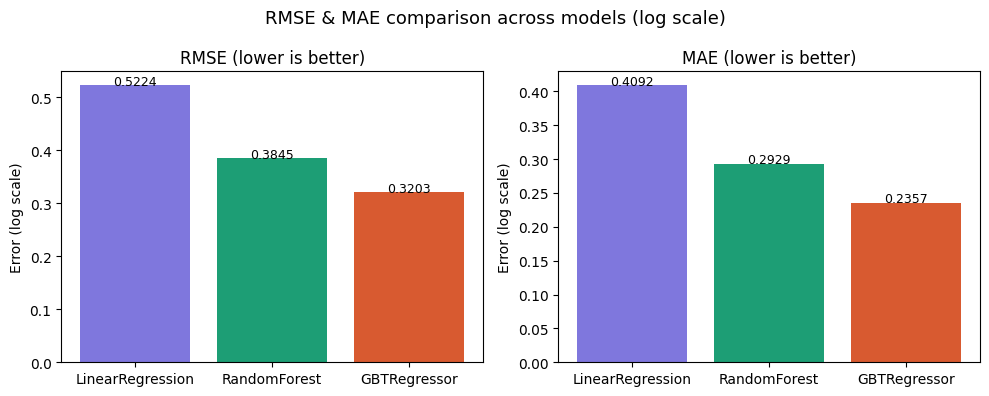

✓ Saved → rmse_mae_comparison.png


In [29]:
# RMSE & MAE bar comparison
fig3, ax3 = plt.subplots(1, 2, figsize=(10, 4))
fig3.suptitle("RMSE & MAE comparison across models (log scale)", fontsize=13)
palette = ["#7F77DD", "#1D9E75", "#D85A30"]

ax3[0].bar(names, rmse_vals, color=palette, edgecolor="none")
ax3[0].set_title("RMSE (lower is better)")
ax3[0].set_ylabel("Error (log scale)")
for i, v in enumerate(rmse_vals):
    ax3[0].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

ax3[1].bar(names, mae_vals, color=palette, edgecolor="none")
ax3[1].set_title("MAE (lower is better)")
ax3[1].set_ylabel("Error (log scale)")
for i, v in enumerate(mae_vals):
    ax3[1].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("plots/rmse_mae_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved → rmse_mae_comparison.png")

---
## 🏆 BONUS — Cross Validation on Best Model

In [30]:
# Cross-validate GBT with hyperparameter tuning
# Uses 20% sample to keep it fast — remove .sample() for full run
print("Running CrossValidator on GBTRegressor …")

gbt_cv = GBTRegressor(
    featuresCol="features", labelCol="log_duration", seed=42
)
pipeline_cv = Pipeline(stages=[assembler, scaler, gbt_cv])

param_grid = (
    ParamGridBuilder()
    .addGrid(gbt_cv.maxDepth, [4, 6])
    .addGrid(gbt_cv.maxIter,  [50, 100])
    .build()
)

cv = CrossValidator(
    estimator=pipeline_cv,
    estimatorParamMaps=param_grid,
    evaluator=evaluator_rmse,
    numFolds=3,
    seed=42
)

cv_train  = train_df.sample(0.2, seed=42)   # remove .sample() for full run
cv_model  = cv.fit(cv_train)
best_gbt  = cv_model.bestModel.stages[-1]

preds_cv = cv_model.bestModel.transform(test_df)
rmse_cv  = evaluator_rmse.evaluate(preds_cv)
r2_cv    = evaluator_r2.evaluate(preds_cv)

print(f"\n🏆 Best GBT after CV:")
print(f"   maxDepth : {best_gbt.getMaxDepth()}")
print(f"   maxIter  : {best_gbt.getMaxIter()}")
print(f"   RMSE     : {rmse_cv:.4f}")
print(f"   R²       : {r2_cv:.4f}")

Running CrossValidator on GBTRegressor …

🏆 Best GBT after CV:
   maxDepth : 6
   maxIter  : 100
   RMSE     : 0.3228
   R²       : 0.8023


---
## 🔮 8. Inference — Predict a Single Trip

In [31]:
import math

def predict_trip(pickup_lat, pickup_lon, dropoff_lat, dropoff_lon,
                 pickup_datetime_str, vendor_id=1, passenger_count=2):
    
    # حساب كل الـ features بـ Python عادي بدون Spark
    from datetime import datetime
    dt = datetime.strptime(pickup_datetime_str, "%Y-%m-%d %H:%M:%S")
    
    hour  = dt.hour
    dow   = dt.isoweekday() % 7 + 1  # 1=Sun like Spark
    month = dt.month
    day   = dt.day
    is_weekend  = 1 if dow in (1, 7) else 0
    is_rush     = 1 if (hour in range(7,10) or hour in range(16,20)) and not is_weekend else 0
    flag_enc    = 0
    
    # Haversine
    R = 6371.0
    lat1, lat2 = math.radians(pickup_lat),  math.radians(dropoff_lat)
    lon1, lon2 = math.radians(pickup_lon),  math.radians(dropoff_lon)
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    haversine = R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    
    # Bearing
    x = math.sin(dlon) * math.cos(lat2)
    y = math.cos(lat1)*math.sin(lat2) - math.sin(lat1)*math.cos(lat2)*math.cos(dlon)
    bearing = (math.degrees(math.atan2(x, y)) + 360) % 360
    
    manhattan = abs(dropoff_lat - pickup_lat) + abs(dropoff_lon - pickup_lon)
    mid_lat   = (pickup_lat + dropoff_lat) / 2
    mid_lon   = (pickup_lon + dropoff_lon) / 2

    feature_vals = [hour, dow, month, day, is_weekend, is_rush,
                    passenger_count, vendor_id, flag_enc,
                    haversine, manhattan, bearing,
                    pickup_lat, pickup_lon, dropoff_lat, dropoff_lon,
                    mid_lat, mid_lon]

    # Predict باستخدام الـ predictions الموجودة — بنعمل pandas row واحدة
    import pandas as pd
    row_pd = pd.DataFrame([feature_vals], columns=feature_cols)
    row_spark = spark.createDataFrame(row_pd)

    print(f"🚕 JFK → Times Square | dist={haversine:.1f}km | hour={hour}")
    for name, res in results.items():
        pred = res["model"].stages[-1]  # اللي اتدرب
        # نستخدم الـ assembler والـ scaler اللي اتدرب
        assembled = assembler.transform(row_spark)
        scaled    = results[name]["model"].stages[1].transform(assembled)
        pred_log = results[name]["model"].transform(row_spark)\
                .select("prediction").toPandas()["prediction"][0]
        print(f"   {name}: {math.expm1(pred_log)/60:.1f} min")


predict_trip(
    pickup_lat=40.6413,  pickup_lon=-73.7781,
    dropoff_lat=40.7580, dropoff_lon=-73.9857,
    pickup_datetime_str="2016-03-14 08:30:00"
)

🚕 JFK → Times Square | dist=21.8km | hour=8
   LinearRegression: 80.2 min
   RandomForest: 54.7 min
   GBTRegressor: 61.2 min


In [32]:
# ── Example 2: Short trip, Saturday afternoon ──────────────────────────────────
predict_trip(
    pickup_lon=-73.9857, pickup_lat=40.7580,   # Times Square
    dropoff_lon=-73.9665, dropoff_lat=40.7812, # Central Park
    pickup_datetime_str="2016-04-09 14:00:00"
)

🚕 JFK → Times Square | dist=3.0km | hour=14
   LinearRegression: 9.8 min
   RandomForest: 12.0 min
   GBTRegressor: 12.4 min


---
## 🚀 9. Export Streamlit App

Writes `streamlit_app.py` to disk.  
To launch: `streamlit run streamlit_app.py`

In [35]:
STREAMLIT_CODE = '''
import streamlit as st
import pandas as pd
import numpy as np
import math, os
from datetime import datetime

st.set_page_config(page_title="NYC Taxi Predictor", page_icon="🚕", layout="wide")

@st.cache_resource
def load_models():
    models_dir = "models"
    required = ["LR_coefficients.npy", "LR_intercept.npy",
                "scaler_mean.npy", "scaler_std.npy"]
    if not all(os.path.exists(f"{models_dir}/{f}") for f in required):
        return {}
    coef      = np.load(f"{models_dir}/LR_coefficients.npy")
    intercept = np.load(f"{models_dir}/LR_intercept.npy")[0]
    mean      = np.load(f"{models_dir}/scaler_mean.npy")
    std       = np.load(f"{models_dir}/scaler_std.npy")
    def predict_fn(feature_vals):
        scaled   = (np.array(feature_vals) - mean) / std
        log_pred = np.dot(scaled, coef) + intercept
        return float(np.expm1(log_pred))
    return {"Linear Regression": predict_fn}

def calc_features(pickup_lat, pickup_lon, dropoff_lat, dropoff_lon,
                  dt_str, vendor_id, pax):
    dt = datetime.strptime(dt_str, "%Y-%m-%d %H:%M:%S")
    hour  = dt.hour
    dow   = dt.isoweekday() % 7 + 1
    month = dt.month
    day   = dt.day
    is_weekend  = 1 if dow in (1, 7) else 0
    is_rush     = 1 if (hour in range(7,10) or hour in range(16,20)) and not is_weekend else 0
    R = 6371.0
    lat1, lat2 = math.radians(pickup_lat),  math.radians(dropoff_lat)
    lon1, lon2 = math.radians(pickup_lon),  math.radians(dropoff_lon)
    dlat = lat2-lat1; dlon = lon2-lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    haversine = R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
    x = math.sin(dlon)*math.cos(lat2)
    y = math.cos(lat1)*math.sin(lat2) - math.sin(lat1)*math.cos(lat2)*math.cos(dlon)
    bearing   = (math.degrees(math.atan2(x, y)) + 360) % 360
    manhattan = abs(dropoff_lat-pickup_lat) + abs(dropoff_lon-pickup_lon)
    mid_lat   = (pickup_lat+dropoff_lat)/2
    mid_lon   = (pickup_lon+dropoff_lon)/2
    return [hour, dow, month, day, is_weekend, is_rush,
            pax, vendor_id, 0,
            haversine, manhattan, bearing,
            pickup_lat, pickup_lon, dropoff_lat, dropoff_lon,
            mid_lat, mid_lon], haversine

# ── UI ───────────────────────────────────────────────────────────────────────
st.title("🚕 NYC Taxi Trip Duration Predictor")
st.caption("Big Data Project · PySpark MLlib · 1.46M rows")

models = load_models()

if not models:
    st.error("No saved models found. Run the training notebook first.")
    st.stop()

tab1, tab2 = st.tabs(["🔮 Single Prediction", "📁 Batch Upload (BONUS)"])

with tab1:
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("📍 Pickup")
        pickup_lat = st.number_input("Pickup Latitude",  value=40.7614, format="%.4f")
        pickup_lon = st.number_input("Pickup Longitude", value=-73.9776, format="%.4f")
        vendor_id  = st.selectbox("Vendor", [1, 2])
        pax        = st.slider("Passengers", 1, 6, 2)
    with col2:
        st.subheader("🏁 Dropoff & Time")
        dropoff_lat = st.number_input("Dropoff Latitude",  value=40.6501, format="%.4f")
        dropoff_lon = st.number_input("Dropoff Longitude", value=-73.9496, format="%.4f")
        dt_str      = st.text_input("Pickup DateTime", value="2016-03-14 08:30:00")
        model_name  = st.selectbox("Model", list(models.keys()))

    if st.button("🚀 Predict"):
        feats, hav = calc_features(pickup_lat, pickup_lon, dropoff_lat, dropoff_lon,
                                   dt_str, vendor_id, pax)
        pred_sec = max(60, models[model_name](feats))
        c1, c2, c3 = st.columns(3)
        c1.metric("Predicted Duration", f"{pred_sec/60:.1f} min")
        c2.metric("In Seconds", f"{pred_sec:.0f} s")
        c3.metric("Distance", f"{hav:.2f} km")
        st.success(f"Model: {model_name}")

with tab2:
    st.info("Upload a CSV with the same columns as train.csv")
    uploaded = st.file_uploader("Upload CSV", type=["csv"])
    if uploaded:
        pdf = pd.read_csv(uploaded)
        st.write(f"Loaded {len(pdf):,} rows")
        st.dataframe(pdf.head())
        model_b = st.selectbox("Model for batch", list(models.keys()), key="batch")
        if st.button("Run Batch Prediction"):
            pdf["pickup_datetime"] = pd.to_datetime(pdf["pickup_datetime"])
            preds = []
            for _, row in pdf.iterrows():
                feats, _ = calc_features(
                    row["pickup_latitude"], row["pickup_longitude"],
                    row["dropoff_latitude"], row["dropoff_longitude"],
                    str(row["pickup_datetime"]), row["vendor_id"], row["passenger_count"]
                )
                preds.append(max(60, models[model_b](feats)))
            pdf["predicted_sec"] = preds
            pdf["predicted_min"] = (pdf["predicted_sec"] / 60).round(2)
            st.dataframe(pdf[["id","predicted_sec","predicted_min"]].head(20))
            st.download_button("⬇️ Download CSV",
                               pdf.to_csv(index=False), "predictions.csv")
'''

with open("streamlit_app.py", "w", encoding="utf-8") as f:
    f.write(STREAMLIT_CODE.strip())

print("✓ streamlit_app.py written")
print("  Run: streamlit run streamlit_app.py")

✓ streamlit_app.py written
  Run: streamlit run streamlit_app.py


In [36]:
!streamlit run streamlit_app.py

^C


---
## 🏁 10. Stop Spark

In [37]:
spark.stop()
print("✓ Spark session stopped")
print("\nOutputs:")
print("  eda_plots.png           — EDA charts")
print("  evaluation_plots.png    — R², Actual vs Predicted, Feature Importance")
print("  rmse_mae_comparison.png — RMSE & MAE bars")
print("  feature_importance.csv  — Feature importance table")
print("  models/                 — Saved PySpark pipelines")
print("  streamlit_app.py        — Deployment app")

✓ Spark session stopped

Outputs:
  eda_plots.png           — EDA charts
  evaluation_plots.png    — R², Actual vs Predicted, Feature Importance
  rmse_mae_comparison.png — RMSE & MAE bars
  feature_importance.csv  — Feature importance table
  models/                 — Saved PySpark pipelines
  streamlit_app.py        — Deployment app
